# K-Means Clustering

In [34]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

In [35]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=k)
y_pred = kmeans.fit_predict(X)

In [36]:
y_pred

array([1, 4, 4, 4, 1, 1, 4, 1, 4, 4, 1, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1,
       4, 1, 4, 4, 1, 1, 1, 4, 4, 1, 1, 1, 4, 4, 1, 1, 4, 1, 1, 4, 4, 1,
       1, 4, 1, 4, 1, 4, 3, 3, 3, 2, 3, 2, 3, 2, 3, 2, 2, 2, 2, 3, 2, 3,
       2, 2, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 3, 3, 2,
       2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 0, 3, 0, 3, 0, 0, 2, 0, 0, 0,
       3, 3, 0, 3, 3, 3, 3, 0, 0, 3, 0, 3, 0, 3, 0, 0, 3, 3, 3, 0, 0, 0,
       3, 3, 3, 0, 0, 3, 3, 0, 0, 3, 3, 0, 0, 3, 3, 3, 3, 3], dtype=int32)

In [37]:
y_pred is kmeans.labels_

True

In [38]:
kmeans.cluster_centers_

array([[7.08695652, 3.12608696, 6.01304348, 2.14347826],
       [5.24285714, 3.66785714, 1.5       , 0.28214286],
       [5.58      , 2.63333333, 3.98666667, 1.23333333],
       [6.29361702, 2.9       , 4.95106383, 1.72978723],
       [4.70454545, 3.12272727, 1.41363636, 0.2       ]])

In [39]:
import numpy as np
X_new = np.array([[0,2],[3,2],[-3,3],[-3,2.5]])
kmeans.predict(X_new)

ValueError: X has 2 features, but KMeans is expecting 4 features as input.

In [40]:
kmeans.transform(X_new)

ValueError: X has 2 features, but KMeans is expecting 4 features as input.

Silhouette score = $(b-a)\over max(a,b)$

In [41]:
# Centroid Initialization Methods
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)

In [42]:
kmeans.fit(X)
kmeans.score(X)

ValueError: The shape of the initial centers (5, 2) does not match the number of features of the data 4.

In [43]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

AttributeError: 'KMeans' object has no attribute 'labels_'

# Clustering for Image Segmentation

In [45]:
from matplotlib.image import imread
import os
image = imread(os.path.join("images", "ladybug.png"))
image.shape

(533, 800, 3)

In [53]:
# reshaping the array to get a long list of RGB colors to cluster
X=  image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

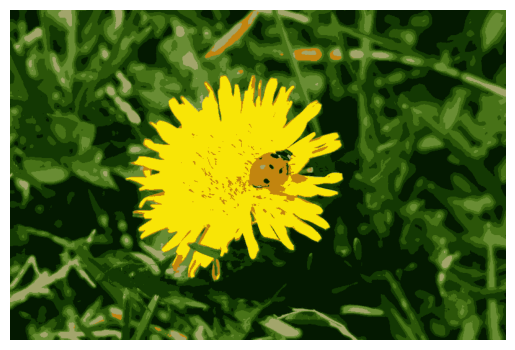

In [56]:
import matplotlib.pyplot as plt

# If segmented_img is float in [0,1], display directly.
# If it's float in [0,255] or cluster centers are floats, convert to uint8:
import numpy as np
if segmented_img.dtype != np.uint8:
    if segmented_img.max() > 1.0:
        seg = np.clip(segmented_img, 0, 255).astype(np.uint8)
    else:
        seg = (np.clip(segmented_img, 0, 1) * 255).astype(np.uint8)
else:
    seg = segmented_img

plt.imshow(seg)
plt.axis('off')
plt.show()


## Using Clustering for Preprocessing

In [58]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

In [60]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
log_reg.score(X_test, y_test)

0.9444444444444444

In [62]:
# Checking if K-Means can improve the accuracy
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression()),
])

pipeline.fit(X_train, y_train)

/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('kmeans', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_clusters,50
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None


In [63]:
pipeline.score(X_test, y_test)

0.9622222222222222

In [64]:
# Using GridSearchCV to find the optimal number of clusters
from sklearn.model_selection import GridSearchCV

param_grid = dict(kmeans__n_clusters=range(2,100))
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 98 candidates, totalling 294 fits


/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ...............................kmeans__n_clusters=2; total time=   0.4s


/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ...............................kmeans__n_clusters=2; total time=   0.3s


...

[CV] END ..............................kmeans__n_clusters=99; total time=   0.8s


/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ..............................kmeans__n_clusters=99; total time=   0.9s


/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimator,Pipeline(step...egression())])
,param_grid,"{'kmeans__n_clusters': range(2, 100)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_clusters,72


In [65]:
grid_clf.best_params_

{'kmeans__n_clusters': 72}

In [66]:
grid_clf.score(X_test, y_test)

0.9622222222222222

## Clustering for Semi-Supervised Learning

In [67]:
n_labeled = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
log_reg.score(X_test, y_test)

0.09111111111111111

In [77]:
k = 50
kmeans = KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

In [78]:
y_representative_digits = np.array([4, 8, 0, 6, 8, 3, 7, 7, 9, 2, 5, 5, 8, 5, 2, 1, 2, 9, 6, 1, 1, 6, 9, 0, 8, 3, 0, 7, 4, 1, 6, 5, 2, 4, 1, 8, 6, 3, 4, 2, 4, 2, 9, 4, 7, 6, 2, 3, 1, 1])

In [79]:
log_reg = LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.06666666666666667

In [80]:
# Label propagation
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [81]:

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/home/sameep/venvs/smp/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.06888888888888889

In [83]:
# only propagating the labels to the 20% of the instances that are closest to the centroids
percentile_closest = 20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dict = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dict, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [88]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.06888888888888889

In [89]:
np.mean(y_train_partially_propagated == y_train[partially_propagated])

np.float64(0.06206896551724138)

# DBSCAN

In [91]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [92]:
dbscan.labels_

array([ 0,  1,  2, -1,  0,  3,  3,  4,  3,  2,  0,  1,  5,  1,  4,  1,  4,
        1,  6,  4,  4,  1,  1,  3,  4,  4,  4,  1,  4,  1,  2,  3,  5,  3,
        3,  3,  3,  4,  2,  1,  1,  4,  3,  1,  3,  1,  0,  6,  3,  1,  4,
        1,  3,  4,  7,  4,  3,  0,  4,  1,  1,  5,  3,  1, -1,  3, -1,  3,
        4,  0,  2,  4,  0,  3,  1,  1,  4,  4,  0,  3,  2,  1,  3,  3,  4,
        3,  1,  4,  0,  3,  7,  1,  1,  4, -1,  3,  3,  1,  1,  1,  3,  1,
        6,  1,  1,  3,  4,  3,  3,  1,  2,  1,  1,  4,  4, -1,  0,  3,  4,
        3,  3,  1,  2,  3,  3,  1,  0,  1,  4,  3,  1, -1,  5,  3,  2,  3,
        2,  3,  1,  1, -1,  3,  0,  5,  2,  1,  2,  4,  1, -1, -1,  6,  4,
        3,  4,  4,  4,  1,  2, -1,  3, -1,  0,  4,  4,  3,  3,  4,  4,  1,
        5,  4,  5,  1,  3,  1,  1, -1,  2, -1,  2,  4,  1,  4,  0,  1,  1,
        5, -1,  3,  2,  1,  7,  2,  6,  3,  3,  6,  3,  1,  2,  1,  3,  1,
        5,  3,  1,  1,  3,  3,  2,  4,  3,  1,  1,  4,  1,  1,  4,  1,  1,
        1, -1,  1,  6,  4

In [94]:
len(dbscan.core_sample_indices_)

808

In [95]:
dbscan.core_sample_indices_

array([  0,   1,   2,   4,   6,   7,   8,   9,  12,  13,  14,  15,  16,
        17,  19,  20,  21,  22,  23,  24,  25,  26,  28,  29,  30,  31,
        34,  35,  36,  37,  38,  40,  41,  42,  43,  44,  45,  46,  47,
        49,  50,  51,  52,  53,  54,  56,  57,  60,  61,  62,  63,  65,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        81,  83,  84,  85,  87,  88,  89,  90,  91,  92,  93,  95,  97,
        98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
       111, 113, 114, 116, 117, 118, 119, 120, 121, 122, 124, 125, 126,
       127, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142,
       143, 144, 145, 146, 147, 148, 152, 153, 154, 155, 156, 157, 158,
       160, 163, 164, 165, 167, 168, 170, 172, 174, 175, 176, 178, 182,
       183, 184, 186, 187, 189, 190, 191, 194, 195, 196, 197, 198, 199,
       200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 211, 212, 213,
       214, 216, 217, 218, 219, 220, 221, 223, 224, 225, 226, 22

In [96]:
dbscan.components_

array([[-0.03871127,  0.46266615],
       [-0.05149331,  1.03282311],
       [ 1.80879558, -0.06287737],
       ...,
       [ 0.45284638, -0.32247236],
       [ 1.68431538, -0.26929352],
       [-1.01578173,  0.20172047]], shape=(808, 2))

In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [98]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)
knn.predict_proba(X_new)

array([[0.22, 0.78, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.32, 0.68, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.04, 0.  , 0.  , 0.96, 0.  , 0.  ]])

In [99]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  4, -1])

# Gaussian Mixture 

In [100]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [101]:
gm.weights_

array([0.2072067 , 0.20685228, 0.58594101])

In [102]:
gm.means_

array([[-0.73954356,  0.57306959],
       [ 1.73107301, -0.06202343],
       [ 0.50262883,  0.24814975]])

In [103]:
gm.covariances_

array([[[ 0.05380404,  0.06132865],
        [ 0.06132865,  0.08515968]],

       [[ 0.05498584,  0.06278088],
        [ 0.06278088,  0.08817795]],

       [[ 0.16780171, -0.09815915],
        [-0.09815915,  0.28835629]]])

In [104]:
gm.converged_

True

In [105]:
gm.n_iter_

16

In [106]:
gm.predict(X) # for hard clustering

array([2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 2, 2, 0,
       0, 1, 2, 2, 2, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 1, 0, 0, 2, 2, 0,
       1, 0, 2, 2, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 2, 1, 0, 2,
       2, 2, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 2, 1, 2, 2,
       1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 2,
       1, 2, 1, 2, 1, 2, 0, 0, 0, 2, 2, 1, 1, 0, 1, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 1, 2, 1, 0, 2, 0,
       2, 2, 1, 2, 1, 2, 0, 2, 2, 2, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 1, 2,
       2, 0, 1, 0, 2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 0, 2, 2, 0, 2, 0,
       0, 0, 2, 0, 2, 2, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1,
       0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 2, 1, 0, 2,
       2, 1, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 2,
       2, 1, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 1, 2, 2,

In [107]:
gm.predict_proba(X) # for soft clustering

array([[1.05563850e-013, 1.26539739e-097, 1.00000000e+000],
       [3.72315215e-003, 2.78529976e-141, 9.96276848e-001],
       [3.03390827e-205, 9.97684642e-001, 2.31535779e-003],
       ...,
       [4.18456647e-078, 2.13663084e-025, 1.00000000e+000],
       [4.00061971e-209, 9.86936014e-001, 1.30639861e-002],
       [9.99854545e-001, 2.34791742e-182, 1.45455034e-004]],
      shape=(1000, 3))

In [108]:
X_new, y_new = gm.sample(6)
X_new

array([[ 1.66145617, -0.12985142],
       [ 0.42708399, -0.13734568],
       [ 0.82224595,  0.78964847],
       [ 0.74307936, -0.04419446],
       [ 0.21151915,  0.23531033],
       [ 0.91563046, -0.85588991]])

In [109]:
y_new

array([1, 2, 2, 2, 2, 2])

In [110]:
gm.score_samples(X)

array([-1.64291322e+00, -2.11750057e+00, -2.06904832e-01, -1.21963423e+00,
       -1.45531362e+00, -2.08643258e+00, -1.66252869e+00, -1.47706307e+00,
       -4.66136570e-01, -5.92641125e-02, -1.51711309e+00, -7.73254762e-01,
       -4.36972036e-01, -5.34531354e-01, -1.60143232e+00, -3.56448300e-01,
       -1.59531973e+00, -8.41100483e-01, -1.89458005e+00, -1.75142087e+00,
       -1.54984039e+00, -5.20104944e-01, -6.78757426e-02, -1.31500959e+00,
       -1.61319580e+00, -1.46864741e+00, -1.60394696e+00, -7.01192513e-01,
       -1.47913012e+00, -1.87255546e+00, -5.19636841e-02, -1.61280594e+00,
       -2.91829442e+00, -2.04306083e+00, -5.12604476e-01, -1.79279604e+00,
       -1.52588063e+00, -1.42371897e+00, -5.05320912e-01, -1.32680240e+00,
       -3.16984347e+00, -1.39159603e+00, -1.54183801e+00, -4.09309665e-01,
       -4.09489280e-01, -1.78034005e-01, -1.95428434e+00, -1.48022952e+00,
       -1.85816934e+00, -7.12414579e-01, -1.55001867e+00, -5.59937736e-01,
       -1.04387891e+00, -

In [113]:
gm.bic(X) # Bayesian Information Criterion

np.float64(2763.5037156922704)

In [114]:
gm.aic(X) # Akaike Information Criterion

np.float64(2680.071875949574)

## Bayesian Gaussian Mixture Models

In [115]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)
np.round(bgm.weights_, 2)

array([0.12, 0.13, 0.14, 0.12, 0.14, 0.14, 0.1 , 0.1 , 0.  , 0.  ])